# Module 4: Transformer Architecture

## Learning Objectives

- Understand the complete transformer encoder-decoder structure
- Learn how encoder and decoder differ
- Implement a full transformer layer
- Trace data flow through the network
- Visualize the complete architecture

**Duration**: ~25 minutes

## 1. Encoder-Decoder Architecture

```
INPUT → ENCODER STACK → DECODER STACK → OUTPUT

ENCODER:                    DECODER:
├─ Multi-Head Attention     ├─ Masked Multi-Head Attention
├─ Feed-Forward Network     ├─ Cross-Attention (to encoder)
└─ Repeat N times           ├─ Feed-Forward Network
                            └─ Repeat N times
```

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print("Module 4: Complete Transformer Architecture")
print("="*60)

Module 4: Complete Transformer Architecture


## 2. Transformer Layer Components

In [2]:
class TransformerLayer(nn.Module):
    """
    Single Transformer Encoder/Decoder Layer
    
    Components:
    1. Multi-Head Attention
    2. Add & Norm (residual connection + layer norm)
    3. Feed-Forward Network
    4. Add & Norm
    """
    
    def __init__(self, d_model=512, num_heads=8, d_ff=2048, dropout=0.1):
        super().__init__()
        
        self.d_model = d_model
        
        # Multi-head attention
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Feed-forward network
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        
        # Layer normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, attn_mask=None, src_key_padding_mask=None):
        """
        Forward pass
        
        Args:
            x: Input (batch, seq_len, d_model)
            attn_mask: Attention mask (e.g., causal mask)
            src_key_padding_mask: Padding mask
        
        Returns:
            output: (batch, seq_len, d_model)
        """
        # Self-Attention with Residual and Norm
        attn_output, _ = self.self_attn(
            x, x, x,
            attn_mask=attn_mask,
            key_padding_mask=src_key_padding_mask
        )
        x = x + self.dropout(attn_output)  # Residual
        x = self.norm1(x)  # Layer Norm
        
        # Feed-Forward with Residual and Norm
        ff_output = self.ff(x)
        x = x + self.dropout(ff_output)  # Residual
        x = self.norm2(x)  # Layer Norm
        
        return x

# Test single layer
layer = TransformerLayer(d_model=512, num_heads=8, d_ff=2048)
x = torch.randn(2, 10, 512)  # (batch, seq_len, d_model)
output = layer(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"✓ Transformer layer working!")

Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])
✓ Transformer layer working!


## 3. Complete Transformer Model

In [3]:
class Transformer(nn.Module):
    """
    Complete Transformer Encoder-Decoder
    """
    
    def __init__(self, vocab_size, d_model=512, num_heads=8, num_layers=6,
                 d_ff=2048, max_seq_len=512, dropout=0.1):
        super().__init__()
        
        self.d_model = d_model
        self.vocab_size = vocab_size
        
        # Embeddings
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_seq_len, d_model)
        
        # Encoder
        self.encoder_layers = nn.ModuleList([
            TransformerLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Decoder
        self.decoder_layers = nn.ModuleList([
            TransformerLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Output
        self.linear_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)
        
        # Layer norm
        self.norm = nn.LayerNorm(d_model)
    
    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        """
        Args:
            src: Source sequence (batch, src_len)
            tgt: Target sequence (batch, tgt_len)
            src_mask: Source padding mask
            tgt_mask: Target causal mask
        """
        batch_size = src.size(0)
        src_len = src.size(1)
        tgt_len = tgt.size(1)
        
        # Encode
        src_pos = torch.arange(src_len, device=src.device).unsqueeze(0)
        enc = self.embed(src) + self.pos_embed(src_pos)
        enc = self.dropout(enc)
        
        for layer in self.encoder_layers:
            enc = layer(enc, src_key_padding_mask=src_mask)
        
        enc = self.norm(enc)
        
        # Decode
        tgt_pos = torch.arange(tgt_len, device=tgt.device).unsqueeze(0)
        dec = self.embed(tgt) + self.pos_embed(tgt_pos)
        dec = self.dropout(dec)
        
        for layer in self.decoder_layers:
            dec = layer(dec, attn_mask=tgt_mask)
        
        dec = self.norm(dec)
        
        # Output
        logits = self.linear_out(dec)
        
        return logits

# Test full transformer
model = Transformer(
    vocab_size=1000,
    d_model=256,
    num_heads=8,
    num_layers=2,
    d_ff=1024
)

src = torch.randint(0, 1000, (2, 10))  # (batch, src_len)
tgt = torch.randint(0, 1000, (2, 12))  # (batch, tgt_len)

output = model(src, tgt)

print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Output shape: {output.shape}")
print(f"Expected shape: ({src.size(0)}, {tgt.size(1)}, 1000)")
print(f"✓ Full transformer working!")

Model Parameters: 3,803,624
Output shape: torch.Size([2, 12, 1000])
Expected shape: (2, 12, 1000)
✓ Full transformer working!


## 4. Architecture Diagram

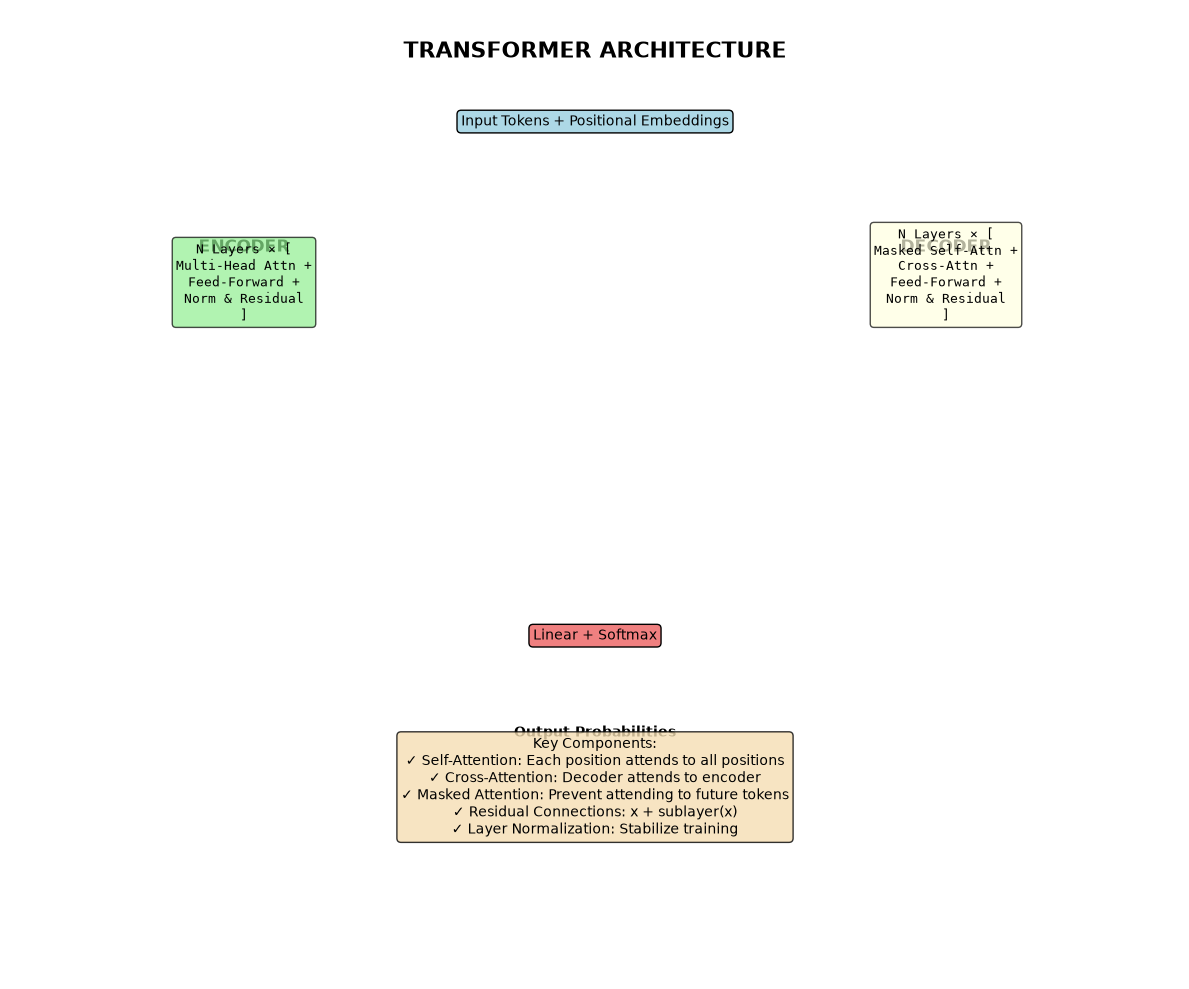

✓ Architecture diagram saved


In [4]:
# Visualize architecture
fig, ax = plt.subplots(figsize=(12, 10))

ax.text(0.5, 0.95, 'TRANSFORMER ARCHITECTURE', 
        ha='center', fontsize=16, weight='bold', transform=ax.transAxes)

# Input
ax.text(0.5, 0.88, 'Input Tokens + Positional Embeddings',
        ha='center', fontsize=10, transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightblue'))

# Encoder
ax.text(0.2, 0.75, 'ENCODER', ha='center', fontsize=12, weight='bold', transform=ax.transAxes)
ax.text(0.2, 0.68, 'N Layers × [\nMulti-Head Attn +\nFeed-Forward +\nNorm & Residual\n]',
        ha='center', fontsize=9, transform=ax.transAxes, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Decoder
ax.text(0.8, 0.75, 'DECODER', ha='center', fontsize=12, weight='bold', transform=ax.transAxes)
ax.text(0.8, 0.68, 'N Layers × [\nMasked Self-Attn +\nCross-Attn +\nFeed-Forward +\nNorm & Residual\n]',
        ha='center', fontsize=9, transform=ax.transAxes, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Output
ax.text(0.5, 0.35, 'Linear + Softmax', ha='center', fontsize=10, transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightcoral'))

ax.text(0.5, 0.25, 'Output Probabilities', ha='center', fontsize=10, weight='bold', transform=ax.transAxes)

# Key concepts
ax.text(0.5, 0.15, 
        'Key Components:\n' +
        '✓ Self-Attention: Each position attends to all positions\n' +
        '✓ Cross-Attention: Decoder attends to encoder\n' +
        '✓ Masked Attention: Prevent attending to future tokens\n' +
        '✓ Residual Connections: x + sublayer(x)\n' +
        '✓ Layer Normalization: Stabilize training',
        ha='center', fontsize=10, transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.savefig('transformer_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Architecture diagram saved")

## 5. Key Takeaways

### ✅ Transformer Architecture

1. **Encoder**: Processes source sequence with self-attention
2. **Decoder**: Processes target sequence with masked self-attention + cross-attention to encoder
3. **Attention mechanisms**: Self-attention, cross-attention, masked attention
4. **Feed-forward networks**: Per-position fully connected layers
5. **Residual connections**: Enable deep networks
6. **Layer normalization**: Stabilize training

### 🎯 Why This Works

- **Parallelizable**: No recurrence, train fast
- **Long-range dependencies**: Direct attention paths
- **Interpretable**: Can visualize attention weights
- **Scalable**: Works with large datasets
- **Modular**: Each component can be modified independently

### 🚀 Next Steps

1. **Notebook 5**: Positional encoding
2. **Notebook 6**: Training transformers
3. **Notebook 7**: Real applications